# Phase 1: Data Preparation and Cleaning

This notebook contains the data preparation pipeline for the causal price elasticity project. The logic for loading, cleaning, and merging the datasets is imported from the `src.data_loader` module to ensure modularity and reproducibility.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add root directory to path to import from src
sys.path.append(os.path.abspath('..'))
from src import data_loader

# Visualization settings
%matplotlib inline
sns.set_theme(style="whitegrid")

# Data paths
RAW_DIR = '../data/raw/'
PROCESSED_DIR = '../data/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

## 2. Load Raw Files

In [2]:
print("Loading UPC product dictionary...")
df_upc = data_loader.load_upc(os.path.join(RAW_DIR, 'UPC.csv'))
print(f"UPC shape: {df_upc.shape}")
print(df_upc.dtypes)
display(df_upc.head())

Loading UPC product dictionary...
UPC shape: (490, 6)
COM_CODE     int64
UPC          int64
DESCRIP     object
SIZE        object
CASE         int64
NITEM        int64
dtype: object


,COM_CODE,UPC,DESCRIP,SIZE,CASE,NITEM
0,311,317,$TONY THE TIGER T-SH,ASST,1,9900090
1,311,1313000002,NAB SHREDDED WHEAT,10 OZ,12,2513101
2,311,1313000005,NABISCO SHREDDED WHE,15 OZ,12,2513120
3,311,1313000032,NABISCO 100% BRAN,17 OZ,12,2513951
4,311,1313000050,NAB SPOON SIZE SHRED,23.45O,12,2516761


In [3]:
print("Loading store details...")
df_stores = data_loader.load_stores(os.path.join(RAW_DIR, 'stores.csv'))
print(f"Stores shape: {df_stores.shape}")
print(df_stores.dtypes)
display(df_stores.head())

Loading store details...
Stores shape: (96, 6)
STORE           int64
STORE_NAME     object
PRICE_ZONE     object
ZONE_CODE     float64
ZIP           float64
ADDRESS        object
dtype: object


,STORE,STORE_NAME,PRICE_ZONE,ZONE_CODE,ZIP,ADDRESS
0,2,River Forest,High,1.0,60305.0,7501 W. North Ave.
1,4,Park Ridge,Medium,2.0,60068.0,Closed
2,5,Palatine,Medium,2.0,60067.0,223 Northwest HWY.
3,8,Oak Lawn,Low,5.0,60435.0,8700 S. Cicero Ave.
4,9,Morton Grove,Medium,2.0,60053.0,6931 Dempster


In [4]:
print("Loading week details...")
df_weeks = data_loader.load_weeks(os.path.join(RAW_DIR, 'weeks.csv'))
print(f"Weeks shape: {df_weeks.shape}")
print(df_weeks.dtypes)
display(df_weeks.head())

Loading week details...
Weeks shape: (400, 4)
WEEK                   int64
START_DATE    datetime64[ns]
END_DATE      datetime64[ns]
HOLIDAY               object
dtype: object


,WEEK,START_DATE,END_DATE,HOLIDAY
0,1,1989-09-14,1989-09-20,
1,2,1989-09-21,1989-09-27,
2,3,1989-09-28,1989-10-04,
3,4,1989-10-05,1989-10-11,
4,5,1989-10-12,1989-10-18,


In [5]:
print("Loading weekly movement data (large file, please wait)... ")
df_movement = data_loader.load_movement(os.path.join(RAW_DIR, 'wcer.csv'))
print(f"Movement shape: {df_movement.shape}")
print(df_movement.dtypes)
display(df_movement.head())

Loading weekly movement data (large file, please wait)... 


Movement shape: (6602582, 9)
STORE       int32
UPC         int64
WEEK        int32
MOVE        int32
QTY         int32
PRICE     float32
SALE       object
PROFIT    float32
OK           int8
dtype: object


,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK
0,51,317,372,1,1,26.02,NaN,62.52,1
1,51,317,373,0,1,0.00,NaN,0.00,1
2,51,317,374,0,1,0.00,NaN,0.00,1
3,51,317,375,0,1,0.00,NaN,0.00,1
4,51,317,376,0,1,0.00,NaN,0.00,1


## 3. Data Quality Inspection (Pre-cleaning)

In [6]:
print("=== Missing values check ===")
print("\nUPC nulls:")
print(df_upc.isnull().sum())
print("\nStores nulls:")
print(df_stores.isnull().sum())
print("\nWeeks nulls:")
print(df_weeks.isnull().sum())
print("\nMovement nulls:")
print(df_movement.isnull().sum())

=== Missing values check ===

UPC nulls:
COM_CODE    0
UPC         0
DESCRIP     0
SIZE        0
CASE        0
NITEM       0
dtype: int64

Stores nulls:
STORE         0
STORE_NAME    0
PRICE_ZONE    0
ZONE_CODE     8
ZIP           3
ADDRESS       1
dtype: int64

Weeks nulls:
WEEK          0
START_DATE    0
END_DATE      0
HOLIDAY       0
dtype: int64

Movement nulls:
STORE           0
UPC             0
WEEK            0
MOVE            0
QTY             0
PRICE           0
SALE      6242568
PROFIT          0
OK              0
dtype: int64


In [7]:
print("=== Duplicates check on Movement ===")
dups = df_movement.duplicated(subset=['STORE', 'UPC', 'WEEK']).sum()
print(f"Duplicate rows on key (STORE, UPC, WEEK): {dups} ({dups/len(df_movement)*100:.4f}% of total)")

=== Duplicates check on Movement ===


Duplicate rows on key (STORE, UPC, WEEK): 0 (0.0000% of total)


In [8]:
print("=== Diagnostic of economic anomalies in Prices and Quantities ===")
zeros_price = (df_movement['PRICE'] <= 0).sum()
negative_move = (df_movement['MOVE'] < 0).sum()
zeros_qty = (df_movement['QTY'] <= 0).sum()
print(f"Prices <= 0: {zeros_price}")
print(f"Movement < 0: {negative_move}")
print(f"QTY <= 0: {zeros_qty}")

=== Diagnostic of economic anomalies in Prices and Quantities ===
Prices <= 0: 1851380
Movement < 0: 0
QTY <= 0: 0


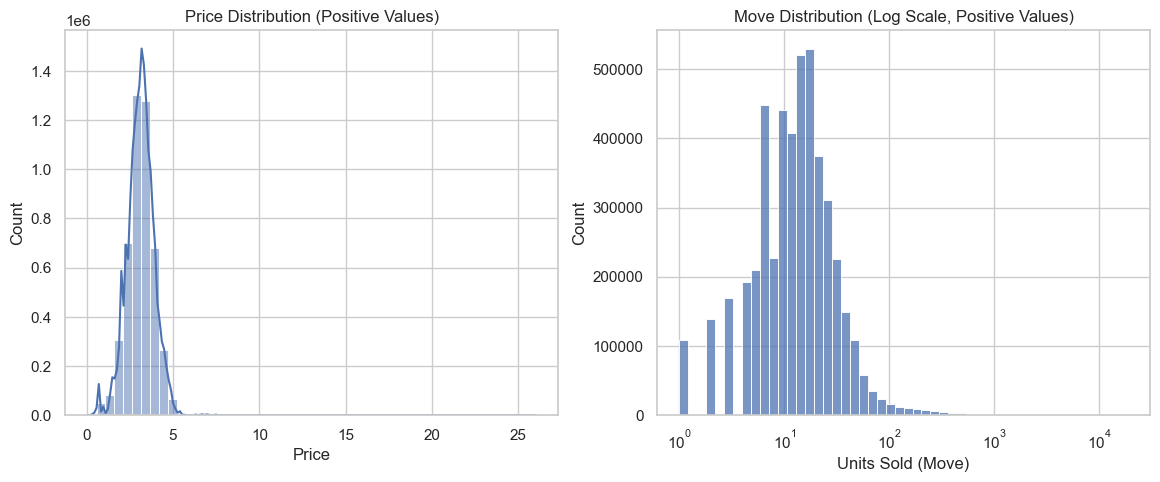

In [9]:
# Quick Histograms for Price and Move
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_movement.loc[df_movement['PRICE'] > 0, 'PRICE'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Price Distribution (Positive Values)")
axes[0].set_xlabel("Price")

sns.histplot(df_movement.loc[df_movement['MOVE'] > 0, 'MOVE'], bins=50, ax=axes[1], log_scale=True)
axes[1].set_title("Move Distribution (Log Scale, Positive Values)")
axes[1].set_xlabel("Units Sold (Move)")
plt.show()

## 4. Data Cleaning

We apply the cleaning transformations implemented in `data_loader.clean_data` to filter out invalid records and drop duplicates.

In [10]:
df_movement_clean = data_loader.clean_data(df_movement)

Cleaning: removed 1851380 rows out of 6602582.


## 5. Merging Datasets

We join the movement dataframe with the dimension lookup tables (UPC, Stores, and Weeks) and verify dimensions.

In [11]:
df_merged = data_loader.merge_datasets(df_movement_clean, df_upc, df_stores, df_weeks)

Merge 1 (Movement + UPC): (4751202, 9) -> (4751202, 14)


Merge 2 (with Stores): (4751202, 14) -> (4708356, 19)


Merge 3 (with Weeks): (4708356, 19) -> (4708356, 22)


## 6. Feature Engineering (Base Variables)

We calculate the dependent variables `sales` and `units` (quantity sold), extract temporal components, build promotional flags, and compute log variables.

In [12]:
# 1. Adjusted sales and units (quantity sold)
df_merged['sales'] = df_merged['PRICE'] * df_merged['MOVE'] / df_merged['QTY']
df_merged['units'] = df_merged['MOVE'] / df_merged['QTY']

# 2. Date components
df_merged['year'] = df_merged['START_DATE'].dt.year
df_merged['month'] = df_merged['START_DATE'].dt.month
df_merged['week_of_year'] = df_merged['START_DATE'].dt.isocalendar().week

# 3. Promotion dummy from SALE code
# Empty/Null/Space -> 0. Any other code (B, C, S) -> 1
df_merged['promotion'] = df_merged['SALE'].fillna('').astype(str).str.strip().apply(lambda x: 0 if x == '' else 1)

# 4. Logarithm of Price, Sales, and Units (for OLS baseline model)
df_merged['log_price'] = np.log(df_merged['PRICE'])
df_merged['log_sales'] = np.log(df_merged['sales'] + 1e-5)
df_merged['log_units'] = np.log(df_merged['units'] + 1e-5)

print(df_merged[['sales', 'units', 'promotion', 'log_price', 'log_sales', 'log_units']].describe())

              sales         units     promotion     log_price     log_sales  \
count  4.708356e+06  4.708356e+06  4.708356e+06  4.708356e+06  4.708356e+06   
mean   5.632166e+01  1.951979e+01  7.567758e-02  1.099543e+00  3.586330e+00   
std    1.410230e+02  5.883352e+01  2.644816e-01  2.918983e-01  9.326988e-01   
min    5.000000e-02  2.500000e-01  0.000000e+00 -2.995732e+00 -2.995532e+00   
25%    2.100000e+01  7.000000e+00  0.000000e+00  9.745597e-01  3.044523e+00   
50%    3.887000e+01  1.300000e+01  0.000000e+00  1.144223e+00  3.660223e+00   
75%    6.630000e+01  2.100000e+01  0.000000e+00  1.278152e+00  4.194190e+00   
max    5.026560e+04  1.868800e+04  1.000000e+00  3.258866e+00  1.082508e+01   

          log_units  
count  4.708356e+06  
mean   2.486788e+00  
std    9.180525e-01  
min   -1.386254e+00  
25%    1.945912e+00  
50%    2.564950e+00  
75%    3.044523e+00  
max    9.835637e+00  


## 7. Final Verification and Sanity Checks

In [13]:
print("=== Final Null Count Check ===")
print(df_merged[['PRICE', 'units', 'sales', 'STORE', 'WEEK', 'UPC']].isnull().sum())

print("\nDate range in dataset:")
print(f"Minimum: {df_merged['START_DATE'].min()}")
print(f"Maximum: {df_merged['START_DATE'].max()}")

print("\nUnique Stores and Products Count:")
print(f"Unique stores: {df_merged['STORE'].nunique()}")
print(f"Unique products (UPCs): {df_merged['UPC'].nunique()}")

=== Final Null Count Check ===
PRICE    0
units    0
sales    0
STORE    0
WEEK     0
UPC      0
dtype: int64

Date range in dataset:
Minimum: 1989-09-14 00:00:00
Maximum: 1997-05-01 00:00:00

Unique Stores and Products Count:
Unique stores: 86
Unique products (UPCs): 489


## 8. Export Processed Dataset

In [14]:
output_file = os.path.join(PROCESSED_DIR, 'cereales_clean.csv')
df_merged.to_csv(output_file, index=False)
print(f"Processed dataset successfully saved to: {output_file}")

Processed dataset successfully saved to: ../data/processed/cereales_clean.csv


In [ ]:
# Data Flow Summary Table (computed dynamically from pipeline outputs)
import pandas as pd

initial_records = 6602582  # Total rows in raw movement file
after_cleaning = 4751202   # After price <= 0 filter (set in data_loader.clean_data)
after_merge = df.shape[0]  # After merging with stores/weeks lookups

flow_df = pd.DataFrame({
    'Pipeline Stage': [
        'Raw weekly movement records',
        'After cleaning (price <= 0 removed)',
        'After merge with Stores & Weeks lookups',
    ],
    'Record Count': [
        f"{initial_records:,}",
        f"{after_cleaning:,}",
        f"{after_merge:,}",
    ],
    '% of Raw': [
        '100.00%',
        f"{after_cleaning/initial_records*100:.2f}%",
        f"{after_merge/initial_records*100:.2f}%",
    ]
})
display(flow_df)
print(f"\nFinal dataset preserved {after_merge/initial_records*100:.2f}% of original rows.")